# Preprocesamiento

1. Cargar datos y parsear timestamps
2. Detectar gaps > 60 segundos y marcar id_segmento
3. Remuestrear a 1 minuto dentro de cada segmento
4. Descartar segmentos con menos de 10 minutos de datos
5. Identificar régimen operacional (0, 1, 2)
6. Filtrar régimen 0 y conservar solo operación
7. Detectar sesiones operacionales y marcar id_sesion
8. Guardar en data/processed/df_operacion.parquet

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import os

sns.set_style('whitegrid')

# 1. Cargar datos y parsear timestamps

In [2]:
datos = pd.read_csv('../data/raw/MetroPT3(AirCompressor).csv',
                parse_dates=['timestamp'])
datos.drop(columns=['Unnamed: 0'], inplace=True)
df = datos.sort_values('timestamp').reset_index(drop = True)
df.head()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


# 2. Verificar fracuencias reales (aparentemente son 10 segundos)

In [3]:
diferencias = df['timestamp'].diff().dt.total_seconds()

print('Frecuencia predominante (segundos):')
print(diferencias.value_counts().head(10))

print("\nGaps mayores a 30 segundos:")
print((diferencias > 30).sum())

print(f'\nGap maximo {diferencias.max():.0f} segundos')
print(f'Gap máximo {diferencias.max()/60:.0f} minutos')
print(f'Gap máximo {diferencias.max()/3600:.0f} horas')

Frecuencia predominante (segundos):
timestamp
10.0    1337521
9.0      128277
12.0      38321
13.0       7988
11.0       4471
21.0         10
19.0          5
22.0          4
20.0          3
17.0          3
Name: count, dtype: int64

Gaps mayores a 30 segundos:
331

Gap maximo 172918 segundos
Gap máximo 2882 minutos
Gap máximo 48 horas


#### Detectar gaps grandes antes de remeustrear

Cuando los gaps son grandes, significa que no fue un error de registro y si fue un paro de operación real y por lo tanto, el final de una sesión de uso.

Con lo anterior se puede ver que hay variaciónes de hasta 13 segundos que se pueden considerar como normales. (7988)

In [4]:
GAP_REGISTRO_SENSOR = 60 # segundos o 1 minuto
# La variación normal más grande es de 13 segundos.
# 1 minuto es como un intervalo de seguridad para esos 13 segundos

df['diff_segundos'] = df['timestamp'].diff().dt.total_seconds()
df['nuevo_segmento'] = (df['diff_segundos'] > GAP_REGISTRO_SENSOR)
df['id_segmento'] = df['nuevo_segmento'].cumsum()

print(f"Total de segmentos: {df['id_segmento'].nunique()}")
df.head(10)

Total de segmentos: 332


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,diff_segundos,nuevo_segmento,id_segmento
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,NaN,False,0
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,10.0,False,0
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,9.0,False,0
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,10.0,False,0
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,10.0,False,0
5,2020-02-01 00:00:49,-0.012,9.306,9.290,-0.024,9.308,53.500,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,10.0,False,0
6,2020-02-01 00:00:59,-0.012,9.296,9.280,-0.024,9.298,53.375,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,10.0,False,0
7,2020-02-01 00:01:09,-0.014,9.286,9.270,-0.024,9.286,53.550,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,10.0,False,0
8,2020-02-01 00:01:19,-0.012,9.276,9.258,-0.022,9.276,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,10.0,False,0
9,2020-02-01 00:01:29,-0.012,9.264,9.248,-0.022,9.264,53.375,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,10.0,False,0


In [5]:
tamaños = df.groupby('id_segmento').size()*10/60 # en minutos
print('Primeros segmentos')
print(tamaños.head())

print('\nTamaño de los segmentos (minutos)')
print(tamaños.describe())

print('\nSegmentos menores a 10 minutos')
print(f'{(tamaños < 10).sum()}')

print('\nSegmentos mayores a 60 minutos')
print(f'{(tamaños > 60).sum()}')

print('\nSegmentos mayroes a 6 hroas')
print(f'{(tamaños > 360).sum()}')

Primeros segmentos
id_segmento
0     775.666667
1     410.000000
2       5.000000
3     185.000000
4    3925.000000
dtype: float64

Tamaño de los segmentos (minutos)
count     332.000000
mean      761.520080
std       957.510374
min         4.833333
25%        25.000000
50%       389.833333
75%      1205.000000
max      6099.833333
dtype: float64

Segmentos menores a 10 minutos
41

Segmentos mayores a 60 minutos
213

Segmentos mayroes a 6 hroas
170


De los 332 segmentos:

| Métrica | Valor | Equivalencia |
|---------|-------|---------------|
| **Media** | 761 min | ≈ 12.7 h |
| **Mínimo** | 4.8 min | ≈ 5 min |
| **Máximo** | 6099 min | ≈ 101 h |



- **25%** de los segmentos duraron **≤ 25 minutos**
- **50%** (mediana) duraron **≤ 389.8 minutos** (≈ 6.5 h)
- **75%** duraron **≤ 1205 minutos** (≈ 20 h)



| Condición | N° segmentos | Destino |
|-----------|--------------|---------|
| **< 10 minutos** | 41 | Descartar porque son muy poquitos |
| **> 60 minutos** | 213 | Pueden tener información |
| **> 6 horas (360 min)** | 170 | **Núcleo para entrenar** |

El dataset contiene 332 segmentos continuos. 170 segmentos tienen duración mayor a 6 horas y concentran la mayor parte de los datos útiles para entrenamiento. Los 41 segmentos menores  a 10 minutos van a tener que ser descartados porque no permiten la construcción de ventanas deslizantes válidas.



#### Las fallas caen en los segmentos grandes?

In [6]:
fallas = [
    '2020-04-18 00:00',
    '2020-05-29 23:30',
    '2020-06-05 10:00',
    '2020-07-15 14:30'
    ]

for falla in fallas:
    ts = pd.Timestamp(falla)
    segmento = df[df['timestamp'] <= ts]['id_segmento'].iloc[-1]
    duracion = tamaños[segmento]
    print(f'\nFalla {falla} --- Segmento {segmento} -- Duración {duracion:.0f} min')


Falla 2020-04-18 00:00 --- Segmento 112 -- Duración 1029 min

Falla 2020-05-29 23:30 --- Segmento 181 -- Duración 1645 min

Falla 2020-06-05 10:00 --- Segmento 191 -- Duración 4028 min

Falla 2020-07-15 14:30 --- Segmento 252 -- Duración 1205 min


# 3. Remuestrear a 1 minuto dentro de cada segmento

Voy a pasar de un dataframe conuna frecuencia irregular aproximada de 10 segundos a otra de un minuto exacto utilizando en las variables modas, medias y una suma

In [7]:
agg_func = {
    'TP2':             'mean',
    'TP3':             'mean',
    'H1':              'mean',
    'DV_pressure':     'mean',
    'Reservoirs':      'mean',
    'Oil_temperature': 'mean',
    'Motor_current':   'mean',
    # Digitales con manejo de vacíos
    'COMP':            lambda x: x.mode()[0] if len(x) > 0 else np.nan,
    'DV_eletric':      lambda x: x.mode()[0] if len(x) > 0 else np.nan,
    'Towers':          lambda x: x.mode()[0] if len(x) > 0 else np.nan,
    'MPG':             lambda x: x.mode()[0] if len(x) > 0 else np.nan,
    'LPS':             lambda x: x.mode()[0] if len(x) > 0 else np.nan,
    'Pressure_switch': lambda x: x.mode()[0] if len(x) > 0 else np.nan,
    'Oil_level':       lambda x: x.mode()[0] if len(x) > 0 else np.nan,
    'Caudal_impulses': 'sum',
}

# 4. Descartar segmentos menores a 10 minutos

In [8]:
segmentos_resampleados = []
for id_segmento, grupo in df.groupby('id_segmento'):

    if len(grupo) < 60: # le VA  a eliminar cada [60 registros crudos * 10 seg(frecuencia original)] = 600 seg = quitar espacios menores a 10 min de informacion
        continue        # para el tamaño total del segmento

    grupo = grupo.set_index('timestamp')
    resampled = grupo.resample('1min').agg(agg_func)

    resampled = resampled.interpolate(method='time', limit = 2) # Para rellenar hasta 2 minutos consecutivos vacíos dentro de los segmentos

    resampled = resampled.dropna()

    resampled['id_segmento'] = id_segmento
    segmentos_resampleados.append(resampled) 

In [9]:
print(f'Segmentos mayores a 10 minutos de duració: {len(segmentos_resampleados)}')
df_min = pd.concat(segmentos_resampleados).reset_index()
print(f"filas   : {df_min.shape[0]:,}")
print(f"columnas: {df_min.shape[1]}")
df_min.head()

Segmentos mayores a 10 minutos de duració: 291
filas   : 252,473
columnas: 17


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,id_segmento
0,2020-02-01 00:00:00,-0.012286,9.327429,9.311143,-0.022857,9.328000,53.521429,0.040357,1.0,0.0,1.0,1.0,0.0,1.0,1.0,7.0,0
1,2020-02-01 00:01:00,-0.013000,9.260000,9.243333,-0.023333,9.259667,53.420833,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0
2,2020-02-01 00:02:00,-0.012667,9.198333,9.182000,-0.022333,9.199000,53.325000,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0
3,2020-02-01 00:03:00,-0.012333,9.136667,9.120667,-0.022667,9.136667,53.200000,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0
4,2020-02-01 00:04:00,-0.013000,9.075667,9.060000,-0.023000,9.075667,53.129167,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0


In [10]:
print(f"Registros originales:         {len(df):,}")
print(f"Registros a 1 minuto:         {len(df_min):,}")
print(f"Factor de reducción:          {len(df)/len(df_min):.1f}x")
print(f"Segmentos conservados:        {df_min['id_segmento'].nunique()}")
print(f"Segmentos descartados (<10m): {df['id_segmento'].nunique() - df_min['id_segmento'].nunique()}")

Registros originales:         1,516,948
Registros a 1 minuto:         252,473
Factor de reducción:          6.0x


Segmentos conservados:        291
Segmentos descartados (<10m): 41


las fallas siguen presentes?

In [11]:
for falla in fallas:
    ts = pd.Timestamp(falla)
    presente = (df_min['timestamp'] <= ts).any()
    print(f"falla {falla} presente en df_ min: {presente}")

falla 2020-04-18 00:00 presente en df_ min: True
falla 2020-05-29 23:30 presente en df_ min: True
falla 2020-06-05 10:00 presente en df_ min: True
falla 2020-07-15 14:30 presente en df_ min: True


# 5. Identificar régimen operacional

#### > Régimenes de operación.
| Estado          | COMP | DV_electric | MPG | LPS                       | Motor_current |
|----------------|------|-------------|-----|---------------------------|---------------|
| APAGADO        | 1    | 0           | 1   | 0 o 1 (depende presión residual) | ≈ 0 A         |
| SIN CARGA (offloaded) | 1    | 0           | 1   | —                        | ≈ 4 A         |
| BAJO CARGA (operación normal) | 0    | 1           | 0   | 0                        | ≈ 7 A         |

También tomar en cuenta 'Motor_current' > 2

In [12]:
df_reg = df_min.copy()
df_reg['regimen'] = 0 # APAGADO
df_reg.loc[(df_reg['DV_eletric'] == 0) & (df_reg['Motor_current'] > 2), 'regimen'] = 1 # Sin carga
df_reg.loc[(df_reg['DV_eletric'] == 1) & (df_reg['Motor_current'] > 2), 'regimen'] = 2 # Con carga

df_reg['regimen'].value_counts()

regimen
0    137733
1     74587
2     40153
Name: count, dtype: int64

# 6. Filtrar y solo conservar regimen 1 y 2

In [13]:
df_reg.head()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,id_segmento,regimen
0,2020-02-01 00:00:00,-0.012286,9.327429,9.311143,-0.022857,9.328000,53.521429,0.040357,1.0,0.0,1.0,1.0,0.0,1.0,1.0,7.0,0,0
1,2020-02-01 00:01:00,-0.013000,9.260000,9.243333,-0.023333,9.259667,53.420833,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,0
2,2020-02-01 00:02:00,-0.012667,9.198333,9.182000,-0.022333,9.199000,53.325000,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,0
3,2020-02-01 00:03:00,-0.012333,9.136667,9.120667,-0.022667,9.136667,53.200000,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,0
4,2020-02-01 00:04:00,-0.013000,9.075667,9.060000,-0.023000,9.075667,53.129167,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,0


Distrinución de los gaps
count    114739.000000
mean          2.675028
std          22.185518
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max        2966.000000
Name: diff_minutos, dtype: float64


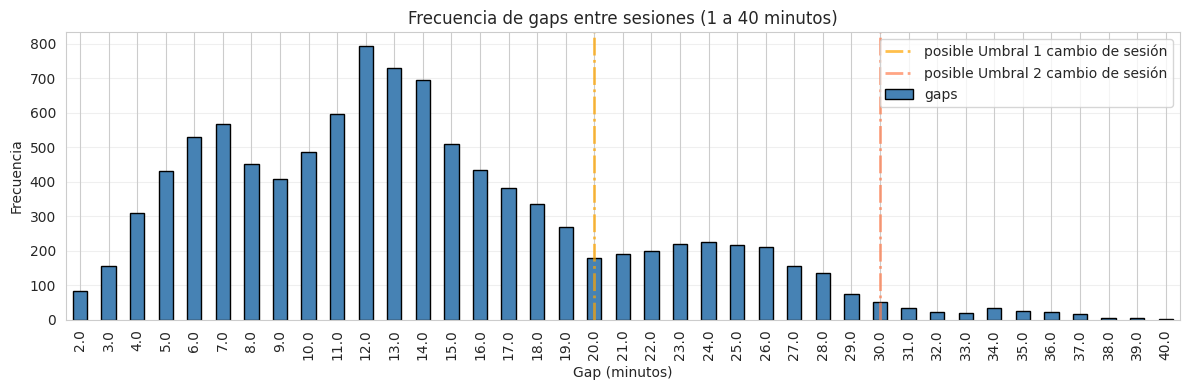

In [14]:
df_op = df_reg.copy()
df_op = df_op[df_op['regimen'] != 0] # Va a dejar los espacios del Régimen 0 libres!!
df_op = df_op.sort_values('timestamp').reset_index(drop = True)

df_op['diff_minutos'] = df_op['timestamp'].diff().dt.total_seconds() / 60

gaps_entre_sesion = df_op['diff_minutos'].dropna()
print('Distrinución de los gaps')
print(gaps_entre_sesion.describe())

os.makedirs('../img/umbral', exist_ok=True)
frecuencias = gaps_entre_sesion.value_counts().sort_index()[1:40]
frecuencias.plot.bar(figsize=(12, 4), color='steelblue', edgecolor='black', label = 'gaps')

plt.axvline(x=18, color='orange', linestyle='-.', linewidth=2, alpha=0.7, label='posible Umbral 1 cambio de sesión')
plt.axvline(x=28, color='coral', linestyle='-.', linewidth=2, alpha=0.7, label='posible Umbral 2 cambio de sesión')
plt.title('Frecuencia de gaps entre sesiones (1 a 40 minutos)')
plt.xlabel('Gap (minutos)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
        f'../img/umbral/umbrales_cambio_sesion.png',
        dpi=150, bbox_inches='tight'
    )
plt.show()

Se podría elegir 20 minutos porque es el final de una caída abrupta en la frecuencia de los gaps, pero en realidad despue de ese valor se tiene aún una gran cantidad de valores en los siguientes gaps. Posterior a los 30 minutos, ya no se consideraría considerable la cantidad y entonces se puede interpretar como un cambio de sesión. ENtonces se elige **30 minutos como un gap** para decir que existe un cambio de sesión.

In [20]:
GAP_ENTRE_SESION = 30.0 # minutos
df_op['nuevo_segmento'] = (df_op['diff_minutos'] > GAP_ENTRE_SESION)  # Los apagados reales tienen gaps de 30+ minutos
df_op['id_sesion'] = df_op['nuevo_segmento'].cumsum()
df_op = df_op.drop(columns=['diff_minutos', 'nuevo_segmento'])
df_op.head()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,id_segmento,regimen,id_sesion
0,2020-02-01 00:23:00,7.468667,8.511667,1.282667,-0.023333,8.509667,49.712500,5.740833,0.0,1.0,0.0,0.0,0.0,1.0,1.0,6.0,0,2,0
1,2020-02-01 00:24:00,8.343000,9.773000,1.671333,-0.023000,9.769333,49.854167,5.814167,0.0,1.0,1.0,0.0,0.0,1.0,1.0,6.0,0,2,0
2,2020-02-01 00:25:00,-0.020000,9.978333,9.970333,-0.022333,9.977000,51.975000,3.881667,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,1,0
3,2020-02-01 00:26:00,-0.013333,9.860667,9.847000,-0.022667,9.860667,53.654167,3.865833,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,1,0
4,2020-02-01 00:27:00,-0.012000,9.781000,9.766000,-0.022333,9.781000,53.241667,3.876250,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,1,0


In [21]:
print(df_op.groupby('id_sesion').size().describe())

count     367.000000
mean      312.643052
std       574.184987
min         3.000000
25%         9.000000
50%        30.000000
75%       429.000000
max      5468.000000
dtype: float64


Tiempo y prorporción de operación

In [22]:
t_total = df_reg['regimen'].value_counts().sum()
t_op = df_op['regimen'].value_counts().sum()

t_op_sin_carga = df_op[df_op['regimen'] == 1]['regimen'].value_counts().sum()
t_op_con_carga = df_op[df_op['regimen'] == 2]['regimen'].value_counts().sum()

print(f"Tiempo total: {t_total:,} minutos")
print(f"Tiempo operación: {t_op:,} minutos")
print(f"Proporción en operación: {t_op / t_total * 100:.1f} %")
print(f"Proporción operación sin carga: {t_op_sin_carga / t_op * 100:.1f} %")
print(f"Proporción operación con carga: {t_op_con_carga / t_op * 100:.1f} %")

Tiempo total: 252,473 minutos
Tiempo operación: 114,740 minutos
Proporción en operación: 45.4 %
Proporción operación sin carga: 65.0 %
Proporción operación con carga: 35.0 %


In [23]:
print(f"Segmentos operacionales: {df_op.groupby('id_sesion').size().count()}")

Segmentos operacionales: 367


SOn los bloques donde el compresor estuvo operando contínuamente con el régimen 1 o 2 sin apagarse por más de 30 minutos. No se incluye al régimen 0 porque se eliminó.

# 7. Guardar en data/processed/operacional.parquet

In [24]:
os.makedirs('../data/processed', exist_ok=True)
df_op.to_parquet('../data/processed/df_operacion.parquet', engine='fastparquet', index = False)
print(f'Guardando {len(df_op):,} registros de operación')

Guardando 114,740 registros de operación
